# GraphCast Operational — Activation Energy Spectrum & Hydrodynamic Entropy

**GraphCast Operational (0.25°, 13 levels, mesh_size=6, M0–M6)**

**No ERA5 data needed** — analysis is purely geometric (W matrix + mesh edges).

| Property | GraphCast Small| GraphCast Operational (this) | GraphCast Full |
|---|---|---|---|
| Resolution | **1.0°** | 0.25° | 0.25° |
| Pressure levels | **13** | 13 | 37 |
| Mesh size (splits) | **5 → M0–M5** | 6 → M0–M6 | 6 → M0–M6 |
| Training data | **ERA5 1979-2015** | ERA5-HRES 1979-2021 | ERA5 1979-2017 |
| Total edges | **81,900** | **3,27,660** |  **3,27,660**  |

In [12]:
# ── CELL 1: Install GraphCast ─────────────────────────────────
%pip install --upgrade https://github.com/deepmind/graphcast/archive/master.zip -q

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [13]:
# ── CELL 2: Imports ───────────────────────────────────────────
import os
import gc
import subprocess
import numpy as np
import xarray as xr
import haiku as hk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import linregress
from graphcast import graphcast, checkpoint, normalization
from graphcast import data_utils, icosahedral_mesh

print("JAX devices :", jax.devices())
print("GraphCast imported OK")

WORK_DIR = "/kaggle/working"
os.makedirs(f"{WORK_DIR}/params", exist_ok=True)

JAX devices : [CpuDevice(id=0)]
GraphCast imported OK


In [14]:
# ── CELL 3a: List bucket to verify filenames ──────────────────
result = subprocess.run(
    ["gsutil", "ls", "gs://dm_graphcast/graphcast/params/"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

gs://dm_graphcast/graphcast/params/GraphCast - ERA5 1979-2017 - resolution 0.25 - pressure levels 37 - mesh 2to6 - precipitation input and output.npz
gs://dm_graphcast/graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz
gs://dm_graphcast/graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz




In [ ]:
# ── CELL 3b: Download GraphCast Operational checkpoint ────────

GCS_PATH = "gs://dm_graphcast/graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz"

PARAMS_LOCAL = f"{WORK_DIR}/params/graphcast_operational.npz"

result = subprocess.run(
    ["gsutil", "cp", GCS_PATH, PARAMS_LOCAL],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)
print("Exit code:", result.returncode)

if result.returncode == 0:
    size = os.path.getsize(PARAMS_LOCAL)
    print(f"Downloaded OK — {size/1e9:.2f} GB")


Copying gs://dm_graphcast/graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz...
/ [0 files][    0.0 B/137.5 MiB]                                                
-
- [0 files][124.5 MiB/137.5 MiB]                                                
- [1 files][137.5 MiB/137.5 MiB]                                                
Operation completed over 1 objects/137.5 MiB.                                    

Exit code: 0
Downloaded OK — 0.14 GB


In [16]:
# ── CELL 4: Load checkpoint ───────────────────────────────────
with open(PARAMS_LOCAL, "rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params       = ckpt.params
state        = {}
model_config = ckpt.model_config
task_config  = ckpt.task_config

print("mesh_size     :", model_config.mesh_size)    # expect 6
print("latent_size   :", model_config.latent_size)   # expect 512
print("gnn_msg_steps :", model_config.gnn_msg_steps)
print("resolution    :", task_config.input_duration)

mesh_size     : 6
latent_size   : 512
gnn_msg_steps : 16
resolution    : 12h


In [17]:
# ── CELL 5: Inspect encoder weight key ───────────────────────
TARGET_KEY = "mesh_gnn/~_networks_builder/encoder_edges_mesh_mlp/~/linear_0"

if TARGET_KEY in params:
    W_shape = np.array(params[TARGET_KEY]["w"]).shape
    b_shape = np.array(params[TARGET_KEY]["b"]).shape
    print(f"Found key  : {TARGET_KEY}")
    print(f"W shape    : {W_shape}   (expect [4, 512])")
    print(f"b shape    : {b_shape}   (expect [512])")
else:
    print("Key NOT found — printing all param keys:")
    for k in sorted(params.keys()):
        print(" ", k)

Found key  : mesh_gnn/~_networks_builder/encoder_edges_mesh_mlp/~/linear_0
W shape    : (4, 512)   (expect [4, 512])
b shape    : (512,)   (expect [512])


In [18]:
# ── CELL 6: Build mesh hierarchy + edge level tags ────────────
# Operational uses mesh_size=6 same as Full → M0..M6
# But only 13 pressure levels (same as Small) — mesh is same as Full

splits = model_config.mesh_size   # 6
R      = 6371.0

print(f"Building icosahedral mesh hierarchy for splits={splits} ...")
meshes      = icosahedral_mesh.get_hierarchy_of_triangular_meshes_for_sphere(splits=splits)
merged_mesh = icosahedral_mesh.merge_meshes(meshes)
all_senders, all_receivers = icosahedral_mesh.faces_to_edges(merged_mesh.faces)

face_levels = np.concatenate([
    np.full(mesh.faces.shape[0], level, dtype=np.int32)
    for level, mesh in enumerate(meshes)
])
edge_levels = np.tile(face_levels, 3)

print(f"\nTotal edges : {len(edge_levels):,}")
print(f"\n{'Level':<6} {'L_km':>9} {'n_edges':>9}")
print("-" * 28)
for lv in range(splits + 1):
    n    = (edge_levels == lv).sum()
    L_km = np.pi * R / (2 * 2**lv)
    print(f"  M{lv}   {L_km:9.0f} {n:9,}")

Building icosahedral mesh hierarchy for splits=6 ...

Total edges : 327,660

Level       L_km   n_edges
----------------------------
  M0       10008        60
  M1        5004       240
  M2        2502       960
  M3        1251     3,840
  M4         625    15,360
  M5         313    61,440
  M6         156   245,760


In [19]:
# ── CELL 7: Sanity check ──────────────────────────────────────
print("face_levels shape :", face_levels.shape)
print("edge_levels shape :", edge_levels.shape)
print()
for level, mesh in enumerate(meshes):
    print(f"M{level} faces shape : {mesh.faces.shape}")

face_levels shape : (109220,)
edge_levels shape : (327660,)

M0 faces shape : (20, 3)
M1 faces shape : (80, 3)
M2 faces shape : (320, 3)
M3 faces shape : (1280, 3)
M4 faces shape : (5120, 3)
M5 faces shape : (20480, 3)
M6 faces shape : (81920, 3)


In [20]:
# ── CELL 8: W·x Hydrodynamic Entropy ─────────────────────────

W = np.array(params[TARGET_KEY]["w"])   # [4, 512]
b = np.array(params[TARGET_KEY]["b"])   # [512]

sender_pos   = merged_mesh.vertices[all_senders]
receiver_pos = merged_mesh.vertices[all_receivers]
diff         = receiver_pos - sender_pos
length       = np.linalg.norm(diff, axis=-1, keepdims=True)
geom         = np.concatenate([diff, length], axis=-1).astype(np.float32)

print(f"geom shape : {geom.shape}")
print(f"W    shape : {W.shape}")
print("Projecting geom @ W + b  ...")

projected = geom @ W + b
print(f"projected shape : {projected.shape}")

del geom, diff, length, sender_pos, receiver_pos
gc.collect()

E_k     = np.zeros(splits + 1)
n_edges = np.zeros(splits + 1, dtype=int)

for level in range(splits + 1):
    mask           = (edge_levels == level)
    n_edges[level] = mask.sum()
    E_k[level]     = float(np.mean(np.sum(projected[mask]**2, axis=-1)))

del projected
gc.collect()

L_km_arr = np.array([np.pi * R / (2 * 2**m) for m in range(splits + 1)])
k_arr    = 1.0 / L_km_arr

print(f"\n{'Level':<6} {'L_km':>8} {'n_edges':>9} {'mean||W·x||²  E(k)':>22}")
print("-" * 54)
for m in range(splits + 1):
    print(f"M{m}    {L_km_arr[m]:8.0f} {n_edges[m]:9,} {E_k[m]:22.4e}")

E_total = E_k.sum()
p_k     = E_k / E_total
S_H     = -np.sum(p_k * np.log2(p_k + 1e-12))
S_max   = np.log2(splits + 1)

print(f"\n{'Level':<6} {'p_k':>10} {'-p log2 p':>12}")
print("-" * 32)
for m in range(splits + 1):
    contrib = -p_k[m] * np.log2(p_k[m] + 1e-12)
    print(f"M{m}    {p_k[m]:10.6f} {contrib:12.6f}")

print(f"\nS_H       = {S_H:.4f} bits")
print(f"S_max     = {S_max:.4f} bits  [= log2({splits+1})]")
print(f"S_H/S_max = {S_H/S_max:.4f}  ({100*S_H/S_max:.1f}%)")
print(f"Dominant  : M{np.argmax(p_k)} ({100*p_k.max():.1f}% of total energy)")

slope, intercept, r_value, *_ = linregress(np.log10(k_arr), np.log10(E_k))
C        = 10**intercept
k_ref    = np.geomspace(k_arr.min(), k_arr.max(), 200)
fit_line = C * k_ref**slope
kolmo    = E_k[0] * (k_ref / k_arr[0])**(-5/3)

print(f"\nPower law  : E(k) = {C:.4e} · k^{slope:.4f}")
print(f"R²         = {r_value**2:.4f}")
print(f"Kolmogorov reference = k^{-5/3:.4f}")

geom shape : (327660, 4)
W    shape : (4, 512)
Projecting geom @ W + b  ...
projected shape : (327660, 512)

Level      L_km   n_edges     mean||W·x||²  E(k)
------------------------------------------------------
M0       10008        60             4.2496e+00
M1        5004       240             1.3084e+00
M2        2502       960             3.4635e-01
M3        1251     3,840             8.8440e-02
M4         625    15,360             2.2880e-02
M5         313    61,440             6.4542e-03
M6         156   245,760             2.3621e-03

Level         p_k    -p log2 p
--------------------------------
M0      0.705393     0.355166
M1      0.217175     0.478452
M2      0.057490     0.236891
M3      0.014680     0.089402
M4      0.003798     0.030537
M5      0.001071     0.010570
M6      0.000392     0.004437

S_H       = 1.2055 bits
S_max     = 2.8074 bits  [= log2(7)]
S_H/S_max = 0.4294  (42.9%)
Dominant  : M0 (70.5% of total energy)

Power law  : E(k) = 1.7800e-07 · k^-1.8459
R² 

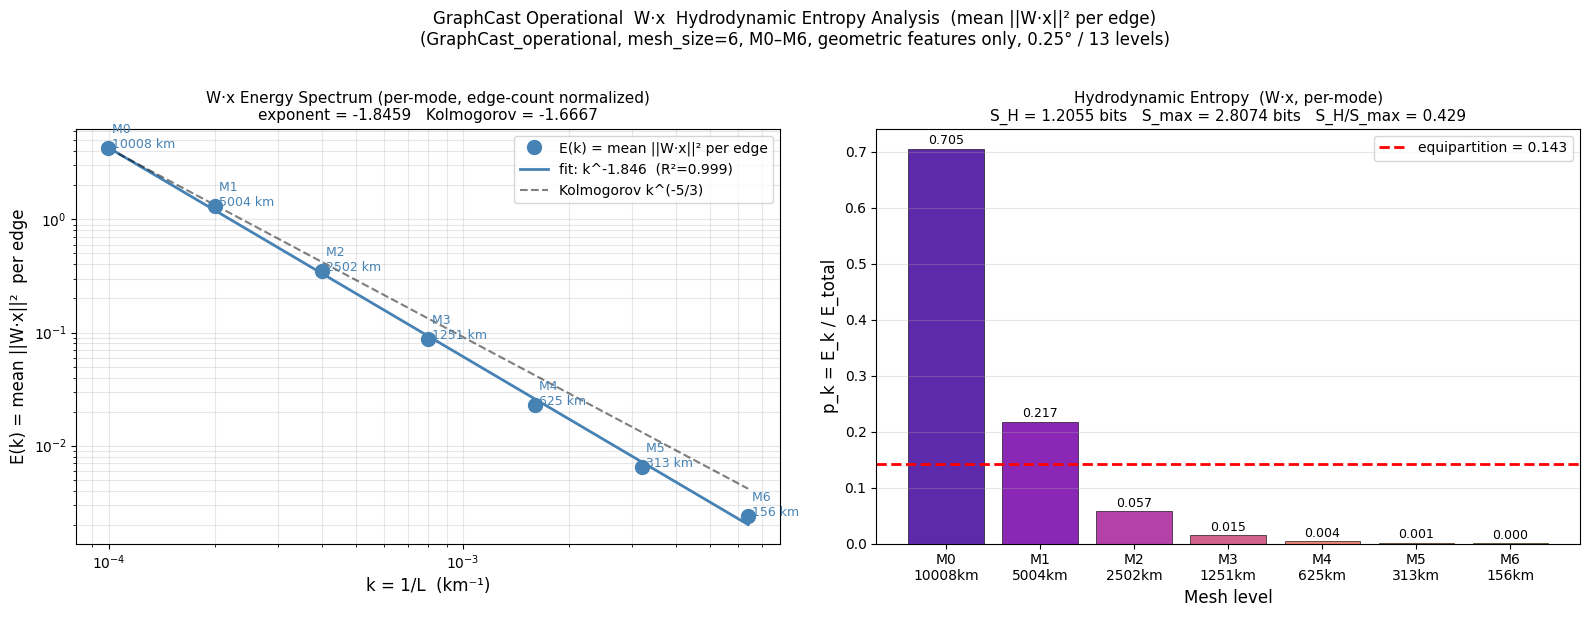

Saved to /kaggle/working/graphcast_operational_Wx_mean_entropy.png


In [21]:
# ── CELL 9: Plot ──────────────────────────────────────────────

colors = plt.cm.plasma(np.linspace(0.1, 0.9, splits + 1))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.loglog(k_arr, E_k, 'o', color='steelblue', ms=10, zorder=5,
          label='E(k) = mean ||W·x||² per edge')
ax.loglog(k_ref, fit_line, '-', color='steelblue', lw=2,
          label=f'fit: k^{slope:.3f}  (R²={r_value**2:.3f})')
ax.loglog(k_ref, kolmo, 'k--', alpha=0.5, label='Kolmogorov k^(-5/3)')
for m in range(splits + 1):
    ax.annotate(f' M{m}\n {L_km_arr[m]:.0f} km',
                xy=(k_arr[m], E_k[m]), fontsize=9, color='steelblue')
ax.set_xlabel("k = 1/L  (km⁻¹)", fontsize=12)
ax.set_ylabel("E(k) = mean ||W·x||²  per edge", fontsize=12)
ax.set_title(
    f"W·x Energy Spectrum (per-mode, edge-count normalized)\n"
    f"exponent = {slope:.4f}   Kolmogorov = {-5/3:.4f}",
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
bars = ax.bar(
    [f'M{m}\n{L_km_arr[m]:.0f}km' for m in range(splits + 1)],
    p_k, color=colors, alpha=0.85, edgecolor='k', lw=0.5
)
ax.axhline(1/(splits+1), color='red', lw=2, linestyle='--',
           label=f'equipartition = {1/(splits+1):.3f}')
for m, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{p_k[m]:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel("Mesh level", fontsize=12)
ax.set_ylabel("p_k = E_k / E_total", fontsize=12)
ax.set_title(
    f"Hydrodynamic Entropy  (W·x, per-mode)\n"
    f"S_H = {S_H:.4f} bits   "
    f"S_max = {S_max:.4f} bits   "
    f"S_H/S_max = {S_H/S_max:.3f}",
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(
    "GraphCast Operational  W·x  Hydrodynamic Entropy Analysis  (mean ||W·x||² per edge)\n"
    "(GraphCast_operational, mesh_size=6, M0–M6, geometric features only, 0.25° / 13 levels)",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/graphcast_operational_Wx_mean_entropy.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {WORK_DIR}/graphcast_operational_Wx_mean_entropy.png")

In [22]:
# ── CELL 10: Summary ──────────────────────────────────────────
print(f"{'='*55}")
print(f"SUMMARY  —  GraphCast Operational  W·x  (mean per edge)")
print(f"{'='*55}")
print(f"Model            : GraphCast Operational  (mesh_size={splits})")
print(f"Resolution       : 0.25°,  13 pressure levels")
print(f"Training data    : ERA5-HRES 1979-2021")
print(f"Mesh levels      : M0 – M6  ({splits+1} levels)")
print(f"Total edges      : {len(edge_levels):,}")
print()
print(f"S_H              : {S_H:.4f} bits")
print(f"S_max = log2({splits+1})  : {S_max:.4f} bits")
print(f"S_H / S_max      : {S_H/S_max:.4f}  ({100*S_H/S_max:.1f}%)")
print(f"Power law exp    : {slope:.4f}  (Kolmogorov = {-5/3:.4f})")
print(f"R²               : {r_value**2:.4f}")
print(f"Dominant level   : M{np.argmax(p_k)} ({100*p_k.max():.1f}% of energy)")
print()
print(f"{'Level':<6} {'L_km':>9} {'n_edges':>9} {'p_k':>10} {'E_k':>14}")
print("-" * 52)
for m in range(splits + 1):
    print(f"M{m}    {L_km_arr[m]:9.0f} {n_edges[m]:9,} {p_k[m]:10.6f} {E_k[m]:14.4e}")

SUMMARY  —  GraphCast Operational  W·x  (mean per edge)
Model            : GraphCast Operational  (mesh_size=6)
Resolution       : 0.25°,  13 pressure levels
Training data    : ERA5-HRES 1979-2021
Mesh levels      : M0 – M6  (7 levels)
Total edges      : 327,660

S_H              : 1.2055 bits
S_max = log2(7)  : 2.8074 bits
S_H / S_max      : 0.4294  (42.9%)
Power law exp    : -1.8459  (Kolmogorov = -1.6667)
R²               : 0.9986
Dominant level   : M0 (70.5% of energy)

Level       L_km   n_edges        p_k            E_k
----------------------------------------------------
M0        10008        60   0.705393     4.2496e+00
M1         5004       240   0.217175     1.3084e+00
M2         2502       960   0.057490     3.4635e-01
M3         1251     3,840   0.014680     8.8440e-02
M4          625    15,360   0.003798     2.2880e-02
M5          313    61,440   0.001071     6.4542e-03
M6          156   245,760   0.000392     2.3621e-03
